# Loading Required Libraries

In [4]:
# Data and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score


In [5]:
# Load the Dataset
df=pd.read_csv('Fraud.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
# shape of Dataset
print("shape:",df.shape)

# Datatypes and non-null counts of columns and rows
df.info()

#statistics summary
df.describe()


shape: (6362620, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [7]:
#Analyzing Frauds vs non-Frauds
print("\nFraud Count:")
print(df['isFraud'].value_counts())

# show percentage
print("\n Fraud Percentage: ")
print(df['isFraud'].value_counts(normalize=True)*100)


Fraud Count:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

 Fraud Percentage: 
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


In [8]:
print("Imbalance")

Imbalance


# Preprocessing the Data

In [9]:
df.drop(['nameOrig', 'nameDest'],axis=1,inplace=True)
print("Dropped")

Dropped


In [13]:
# Transactions where money sends but balance didn't change
weird_rows=df[(df['amount']>0)& (df['oldbalanceOrg'] > 0 ) & (df['newbalanceOrig'] == df['oldbalanceOrg'])]

# Remove them
df=df.drop(weird_rows.index)
print("Cleaned")

Cleaned


In [14]:
le=LabelEncoder()
df['type'] = le.fit_transform(df['type'])
print("Encoded")

Encoded


# Featured Engineering

In [16]:
df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
df['errorBalanceDest'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']
print("Created")

Created


In [17]:
# Taking just 3% of dataset for efficient performance
df_sample=df.sample(frac=0.03,random_state=42)

#Redefining X and y from the sample
X=df_sample.drop(['isFraud','isFlaggedFraud'],axis=1)
y=df_sample['isFraud']
print("Sampled")

Sampled


# Preparing Data for Modeling

In [18]:
# split dataset
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
print("Split")

Split


# Train The Model

In [19]:
model = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Trained")

Trained


# Evaluate The Model

In [20]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score

print("Classification Report:\n",classification_report(y_test,y_pred))
print("ROC-AUC:",roc_auc_score(y_test,y_pred))
print("Evaluated")

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     38126
           1       1.00      1.00      1.00        50

    accuracy                           1.00     38176
   macro avg       1.00      1.00      1.00     38176
weighted avg       1.00      1.00      1.00     38176

ROC-AUC: 1.0
Evaluated


# Feature Importance Analysis

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

#Get feature importance
importances = model.feature_importances_
features = X.columns

In [22]:
# create Dataframe
importance_df = pd.DataFrame({'Feature': features,'Importance': importances})
importance_df.sort_values(by='Importance',ascending=False,inplace=True)

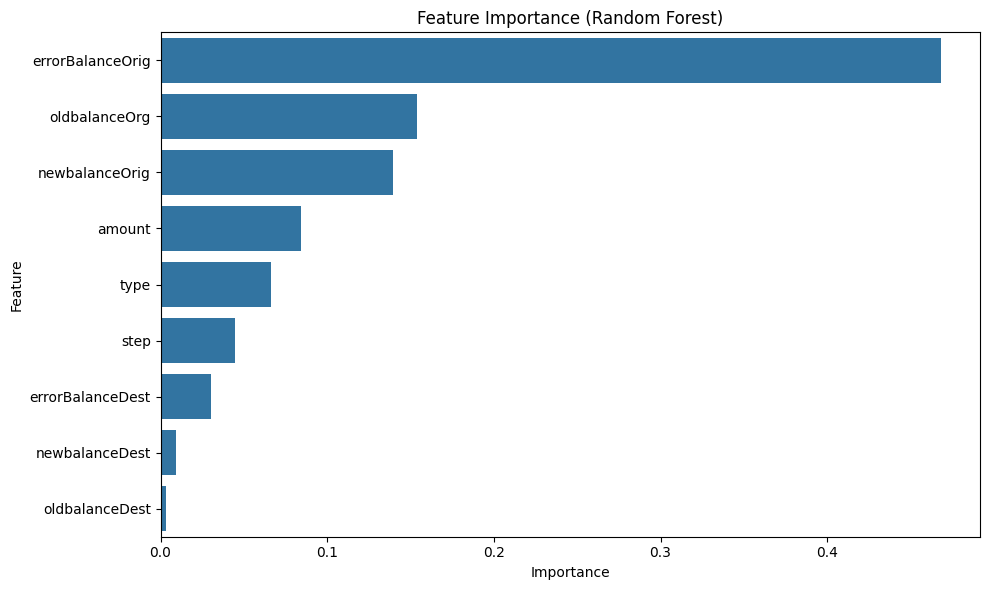

In [23]:
# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='Feature',data=importance_df)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()
